Best parameters usati per i grafici
CSV disponibili:
   /home/destro/sciantix-official/results_model_variants/variant_all_runs.csv exists= True
   /home/destro/sciantix-official/results_model_variants/variant_best_by_model.csv exists= True
------------------------------------------------------------------------------------------------------------------------------------
model |                              label |          f_n |          K_d |  g_d_scale |  seed_nm |        score |    source
------------------------------------------------------------------------------------------------------------------------------------
   M0 |                        M0 baseline |    1.000e-10 |    3.000e+05 |        0.5 |        0 |       1.3375 |       csv
   M1 |              M1 baseline, P2 score |    1.000e-10 |    3.000e+05 |        0.5 |        0 |       1.3375 |  fallback
   M2 |                 M2 nucleation mass |    1.000e-09 |    5.000e+05 |          1 |        0 |       1.2839 |       cs

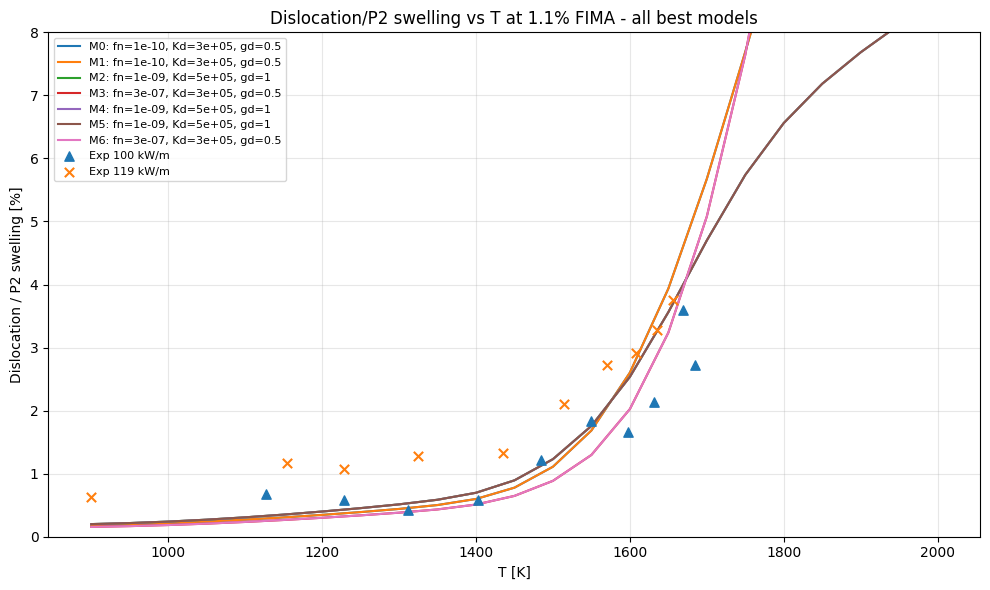

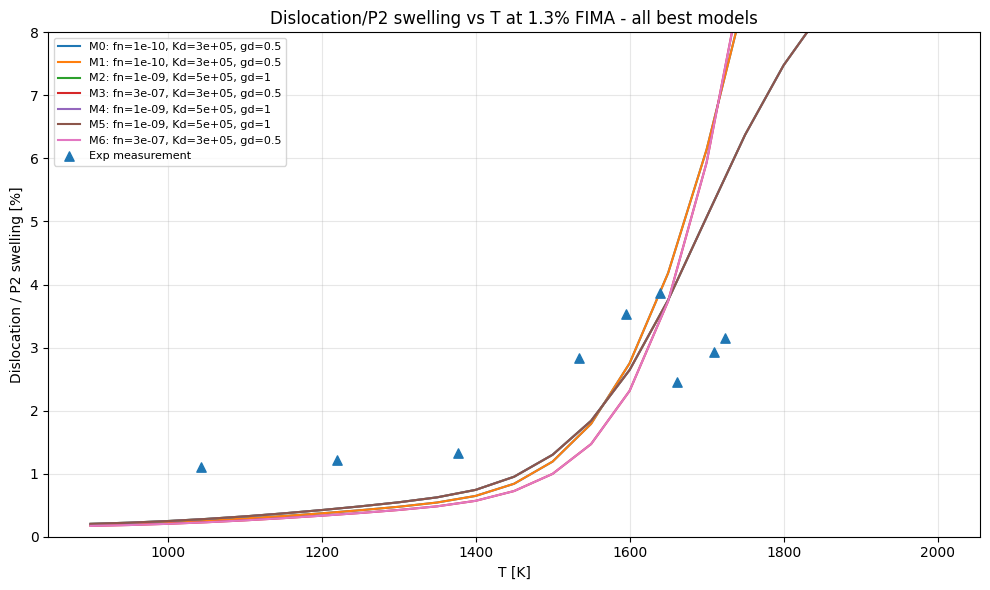

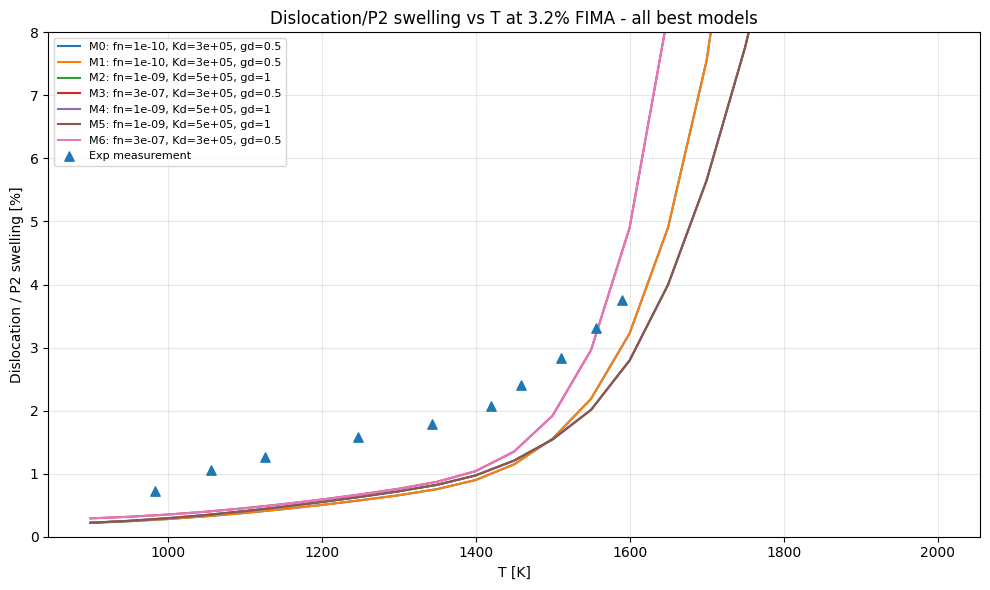

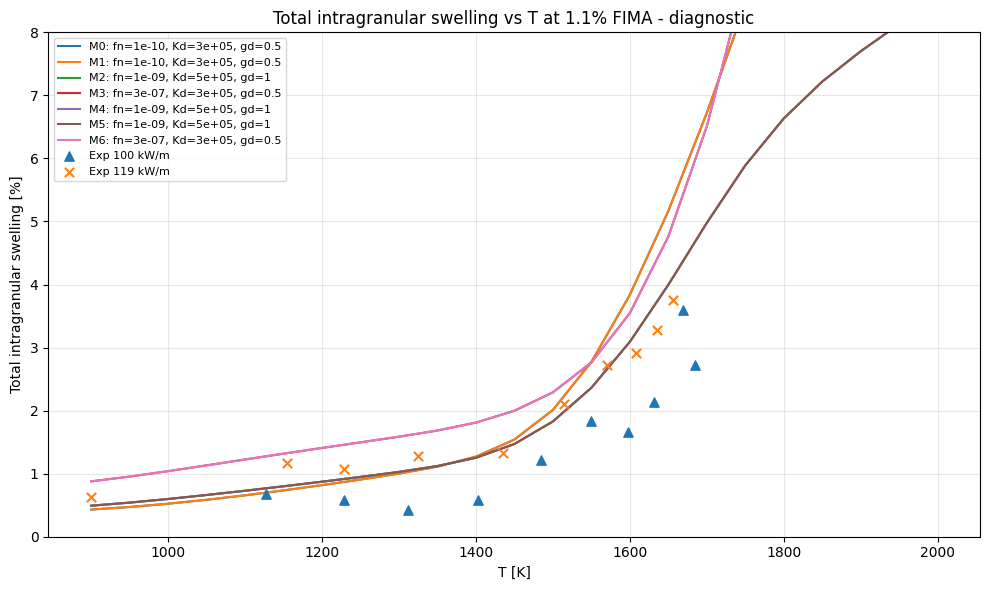

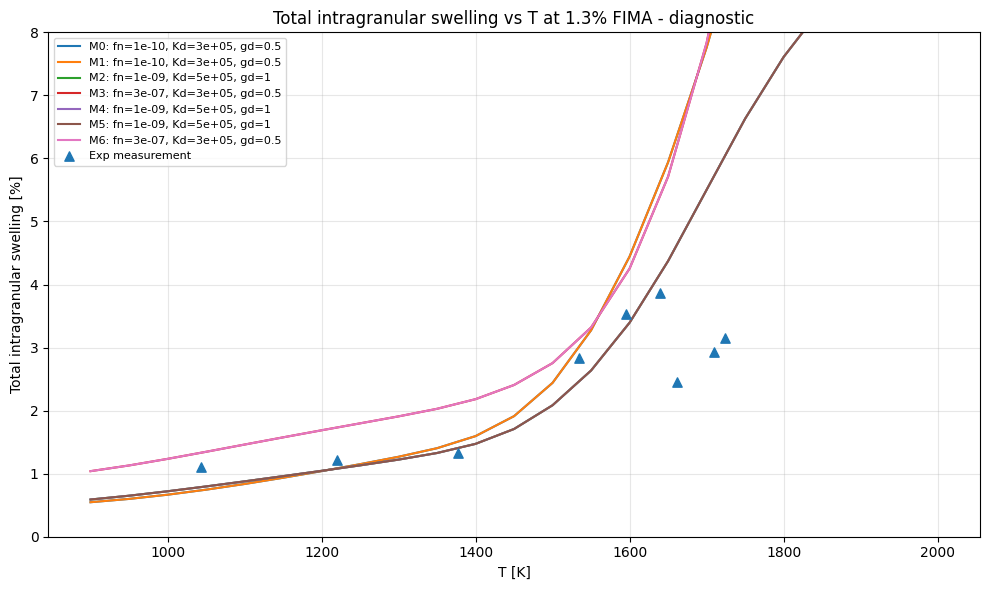

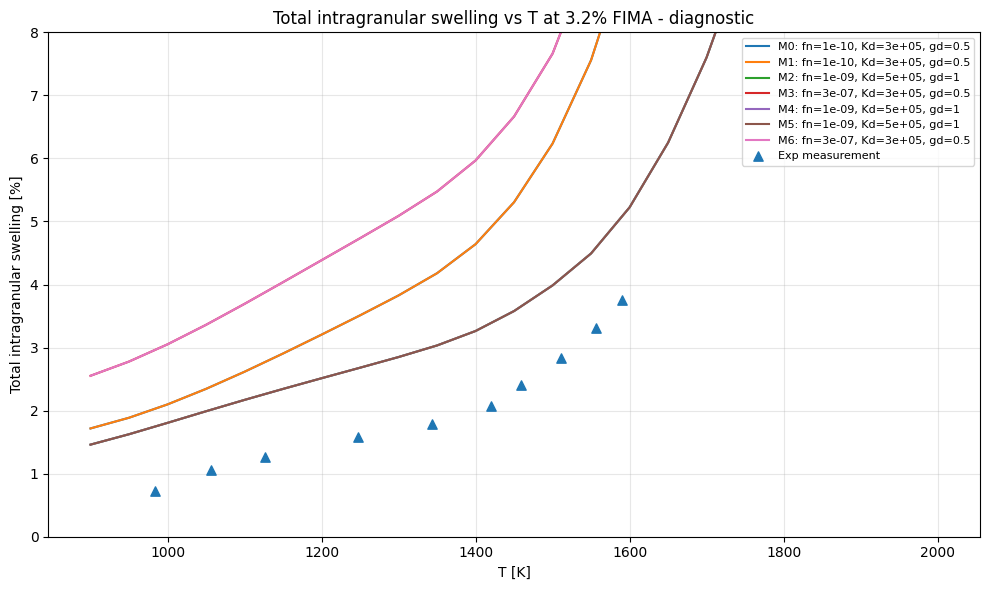

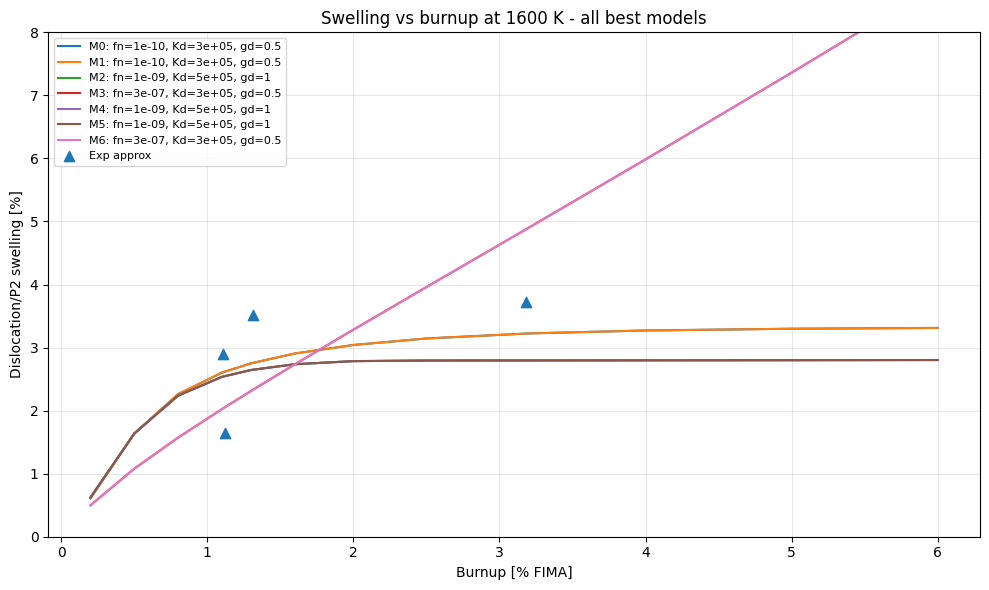

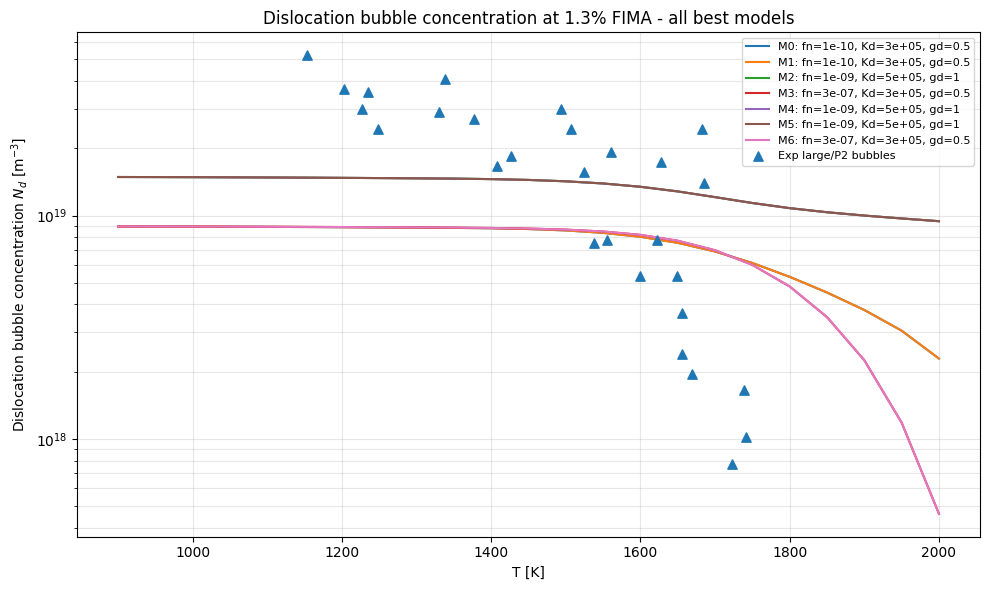

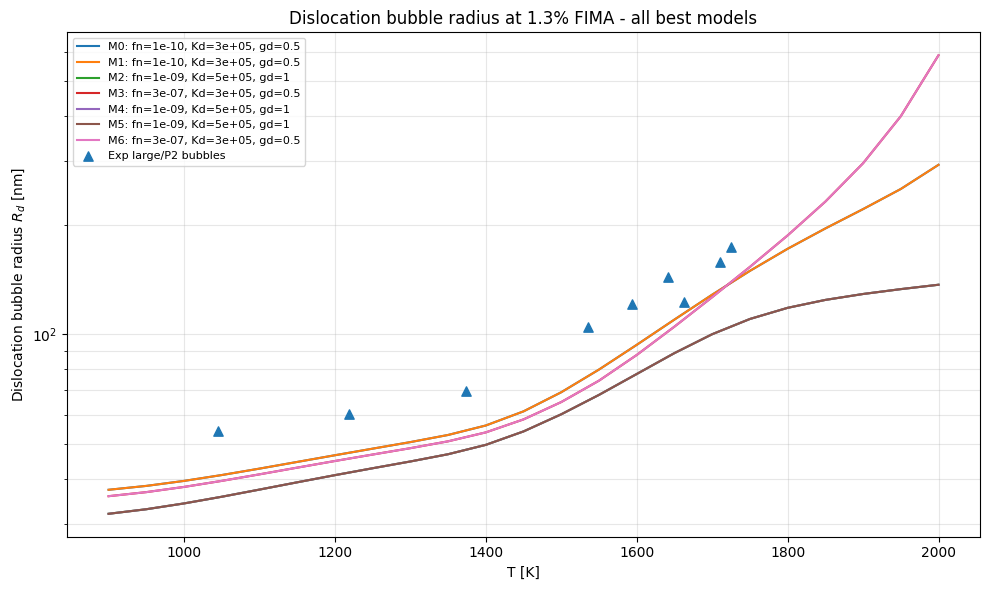

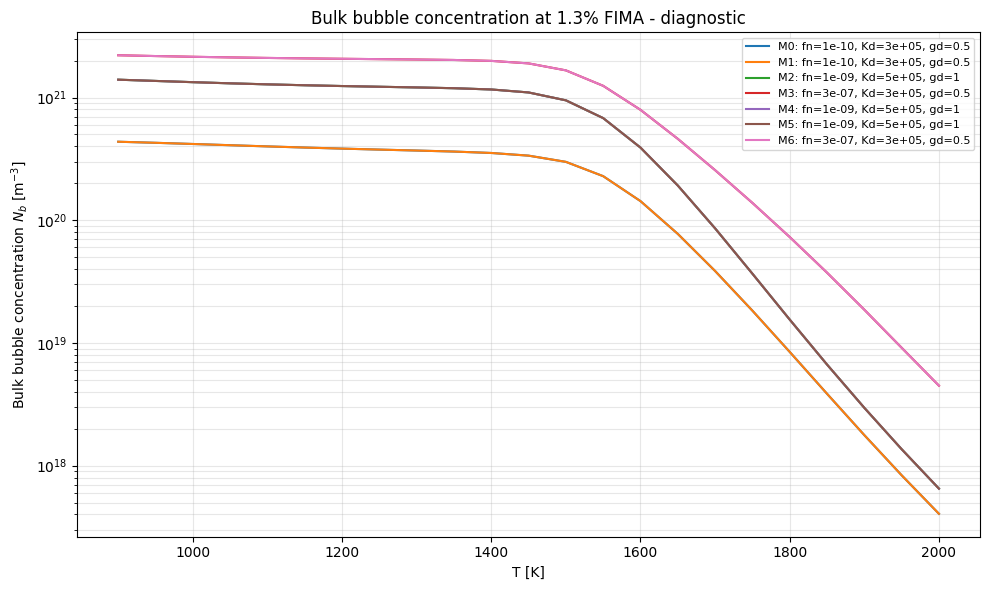

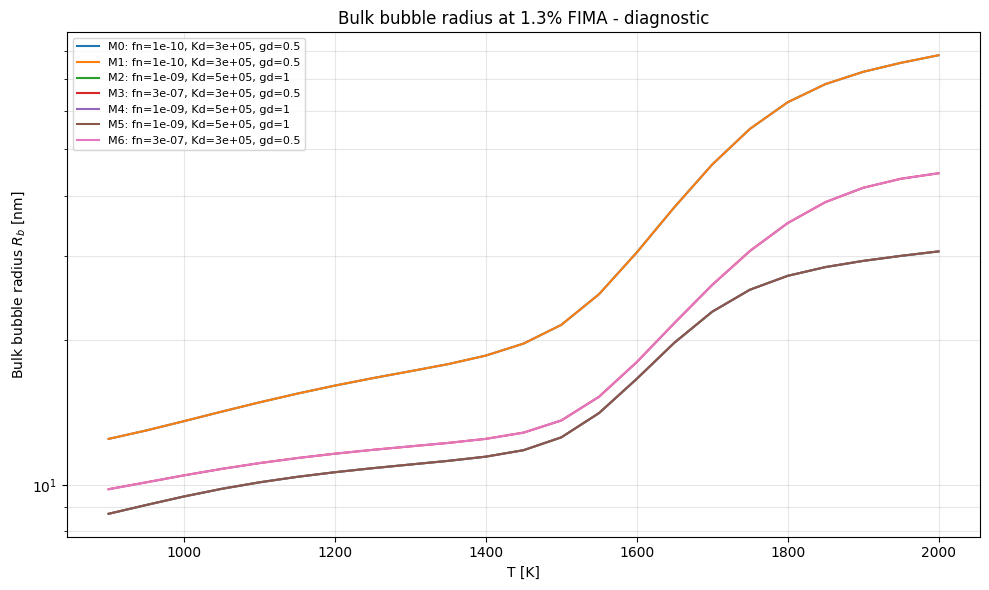

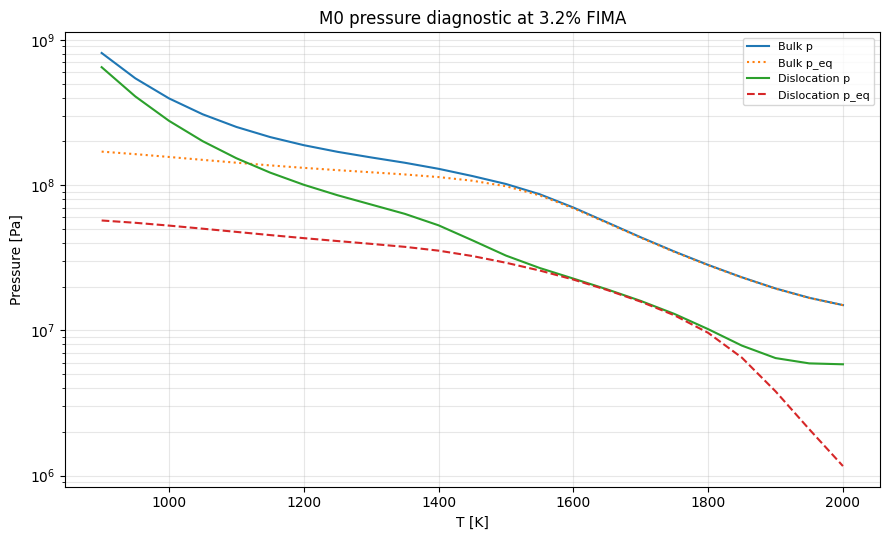

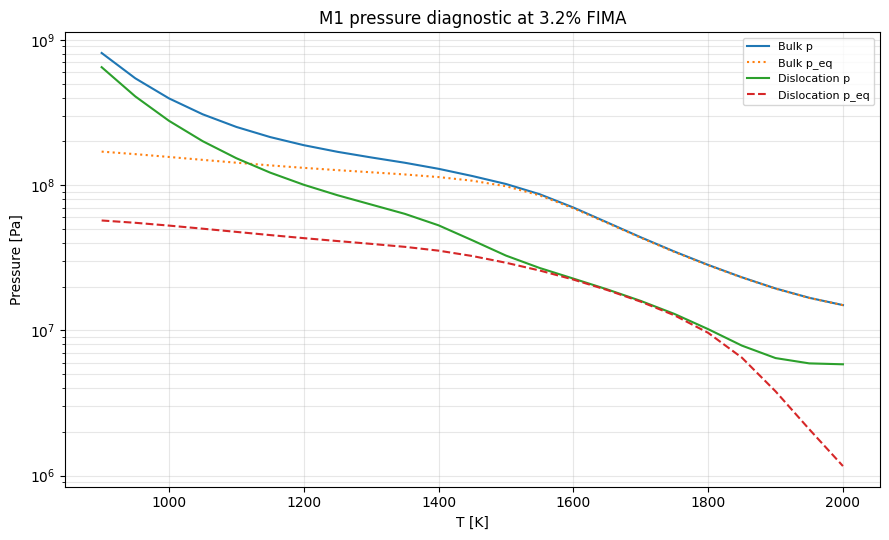

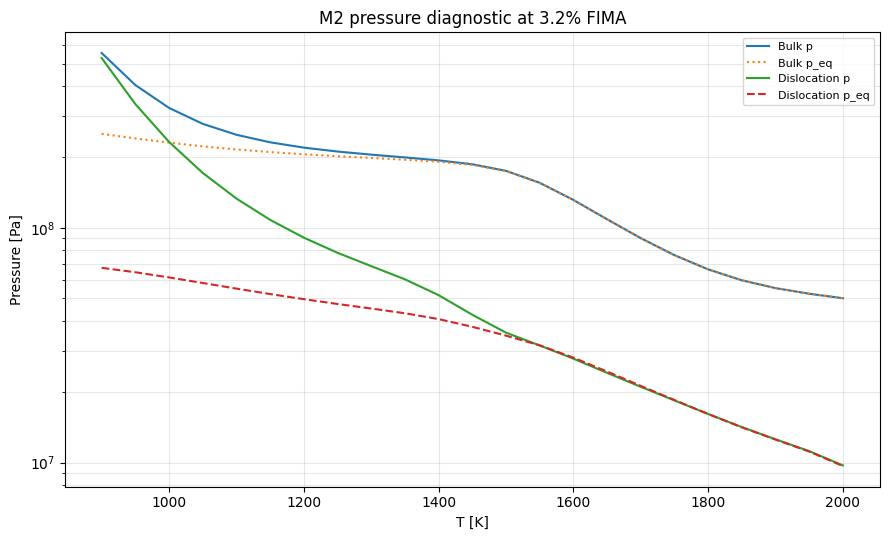

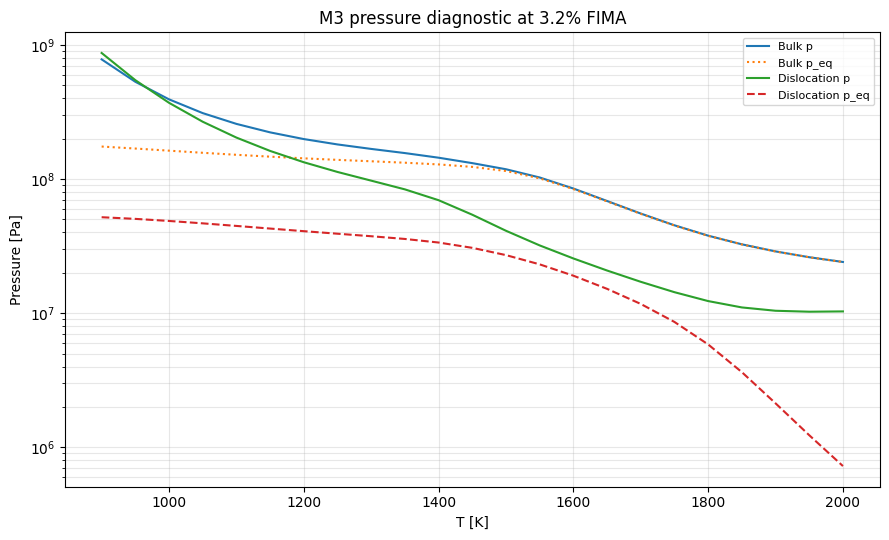

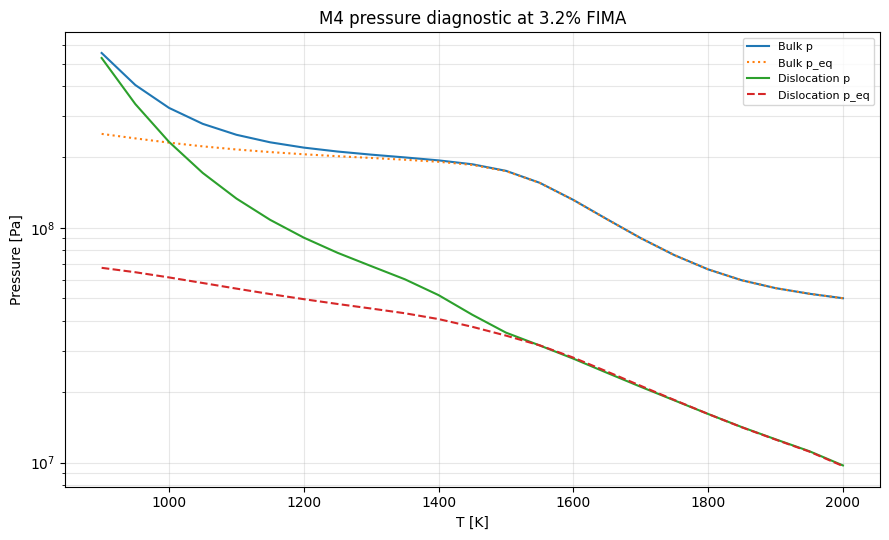

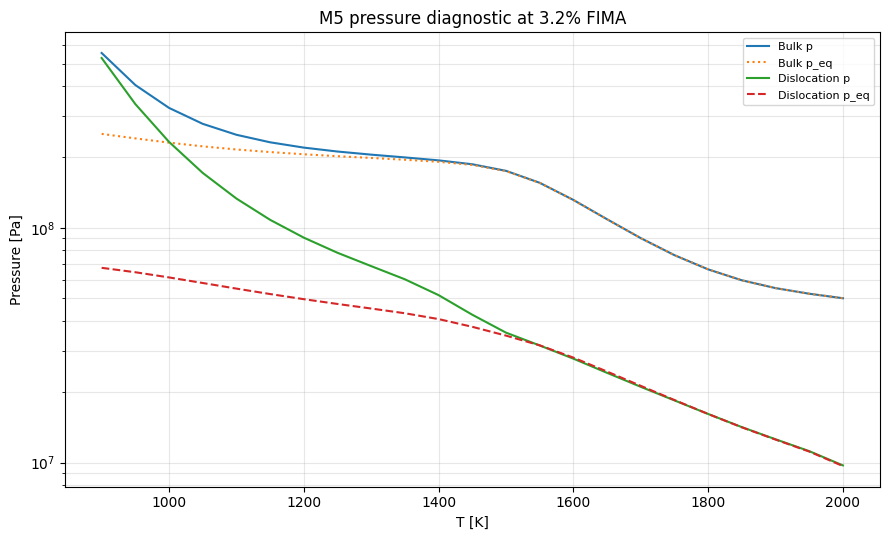

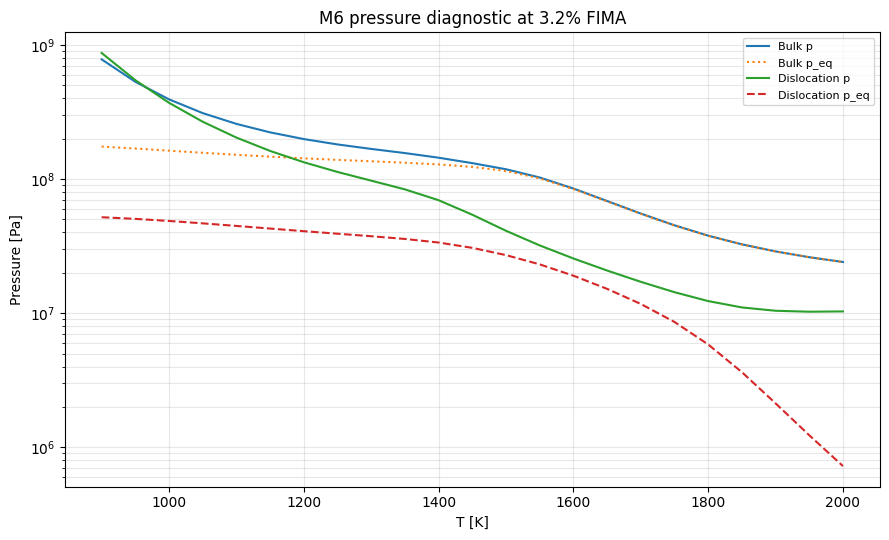

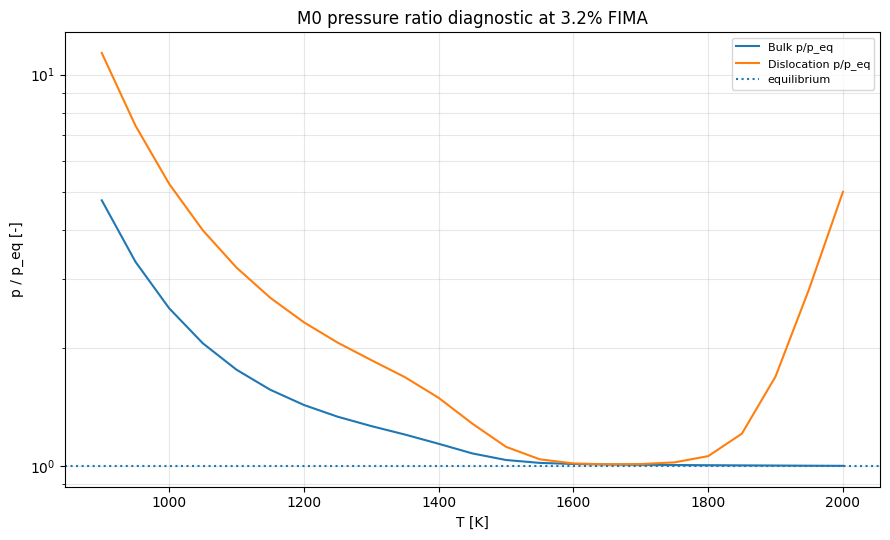

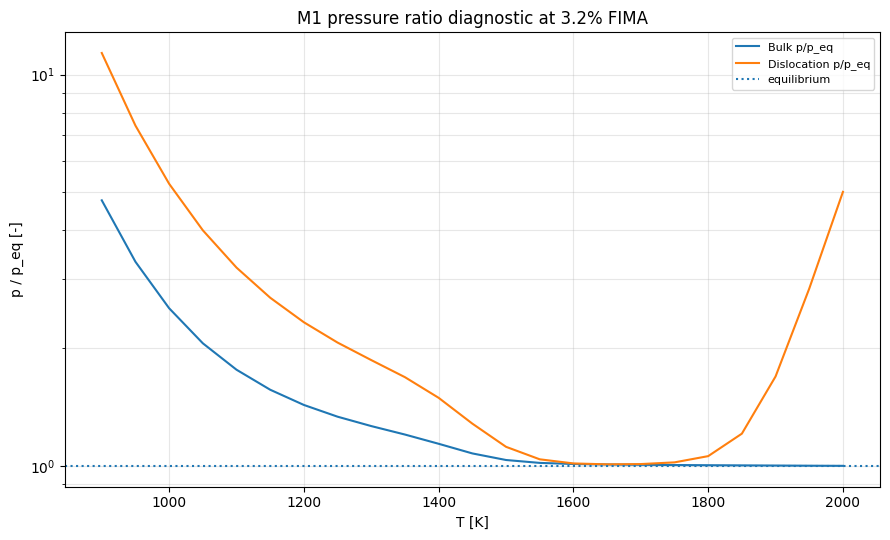

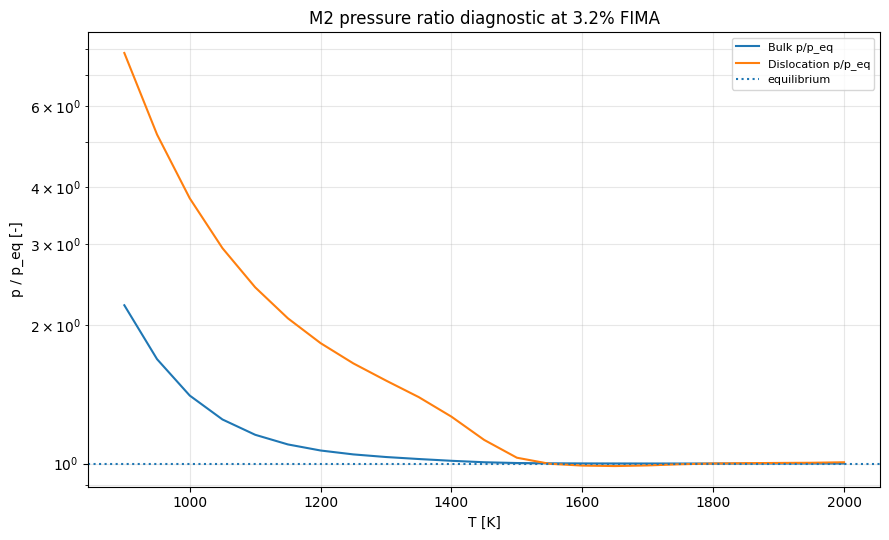

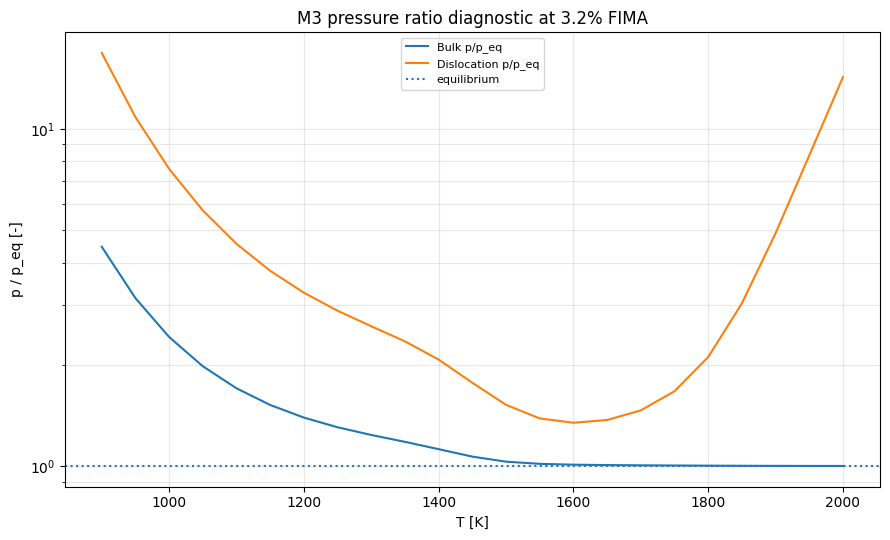

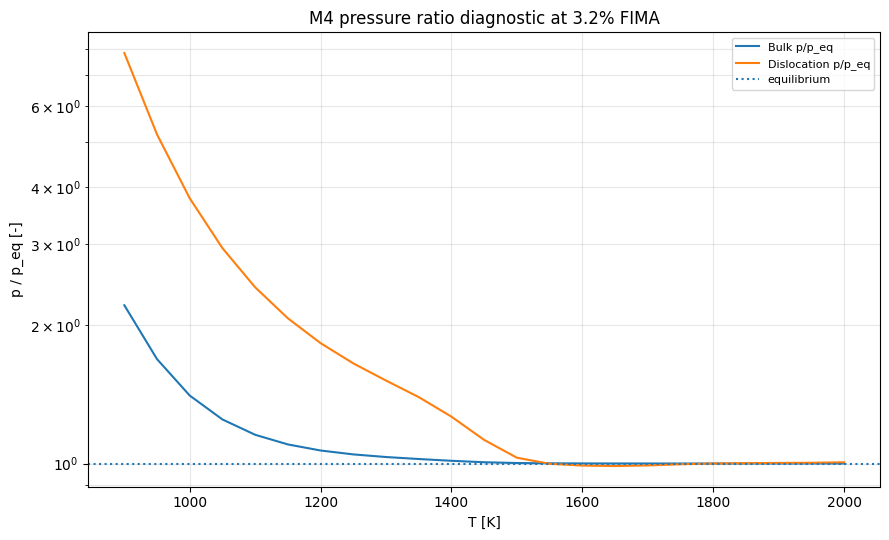

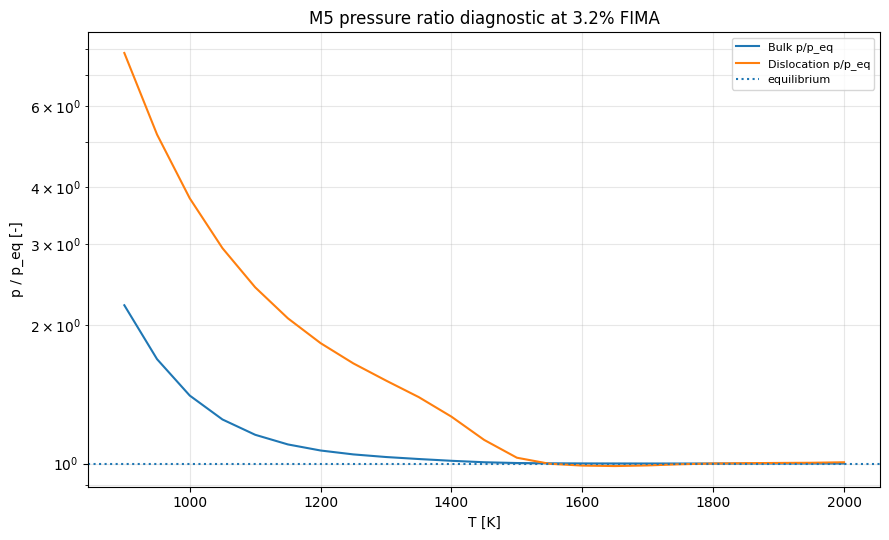

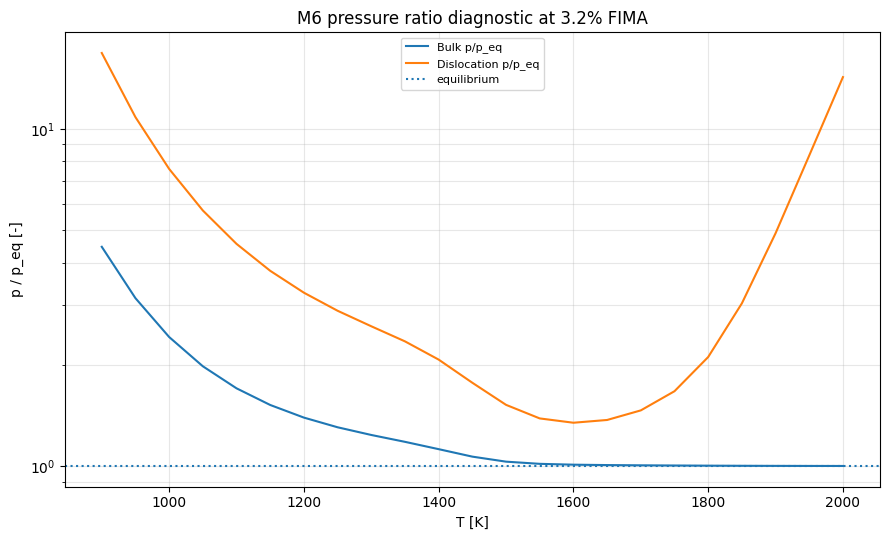

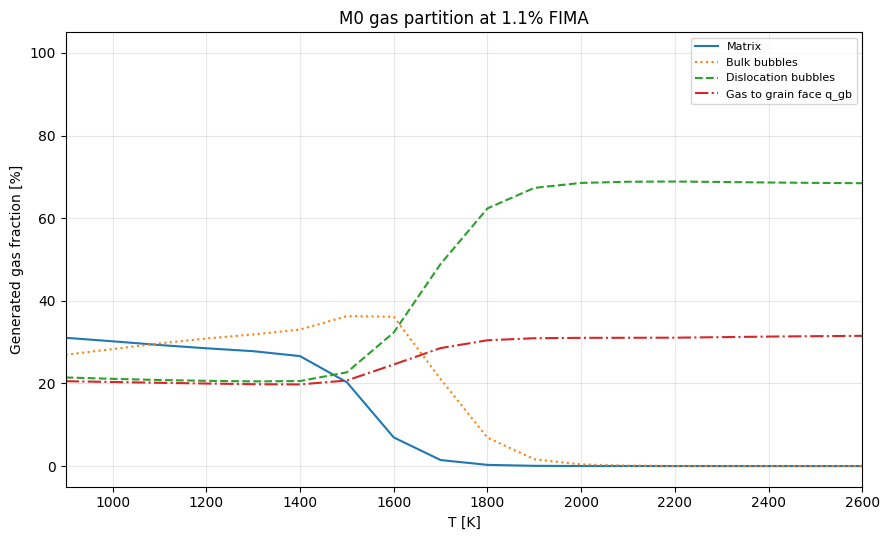

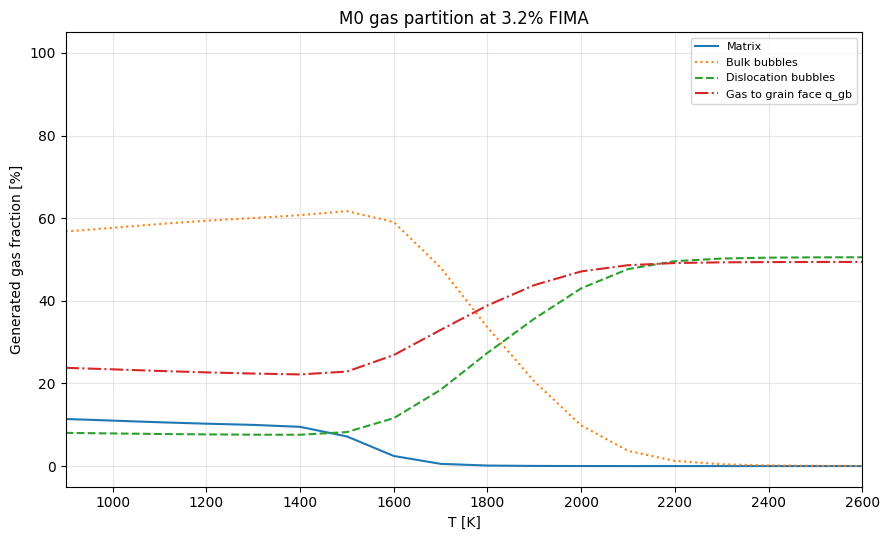

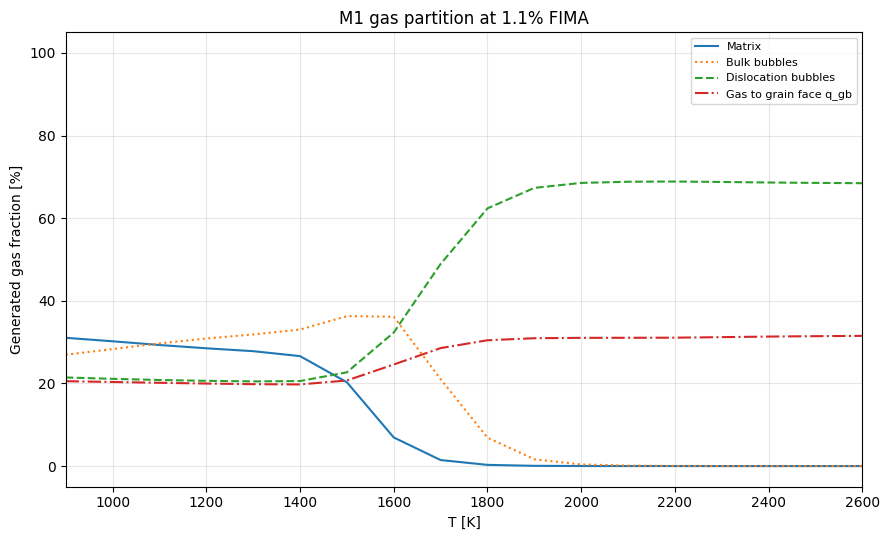

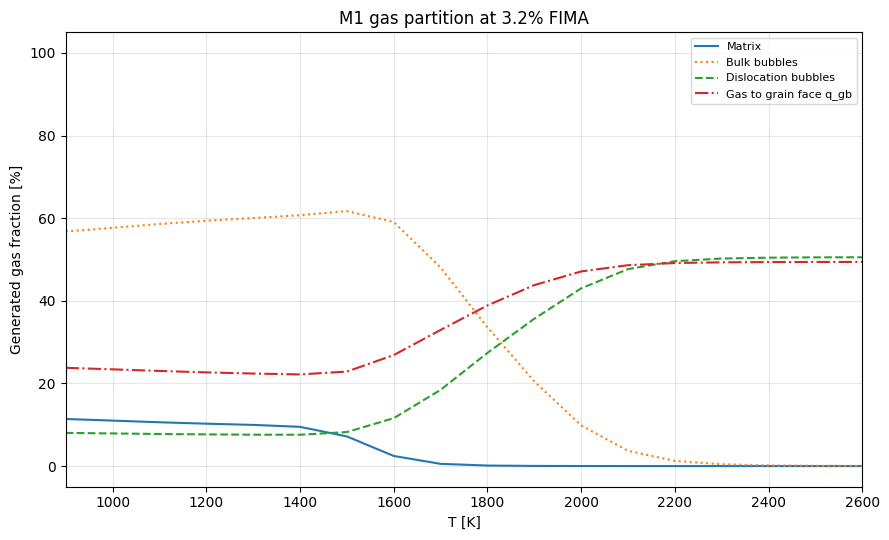

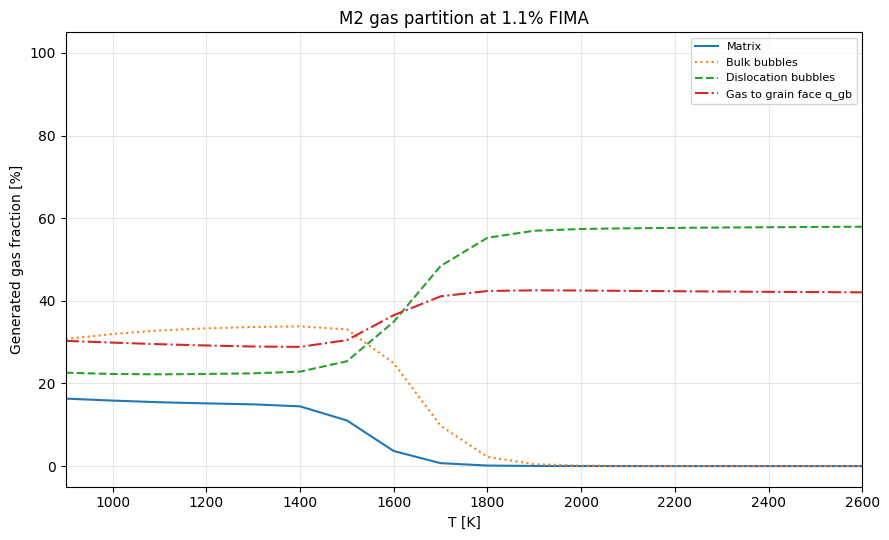

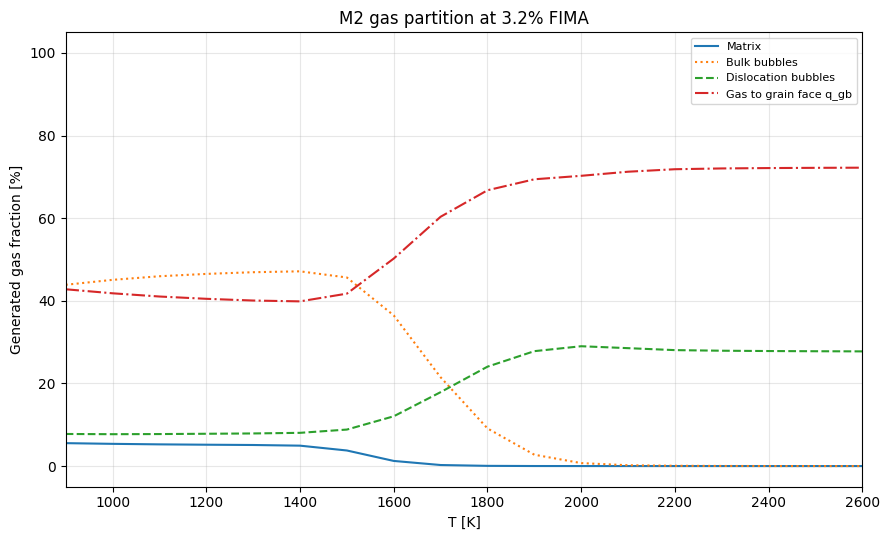

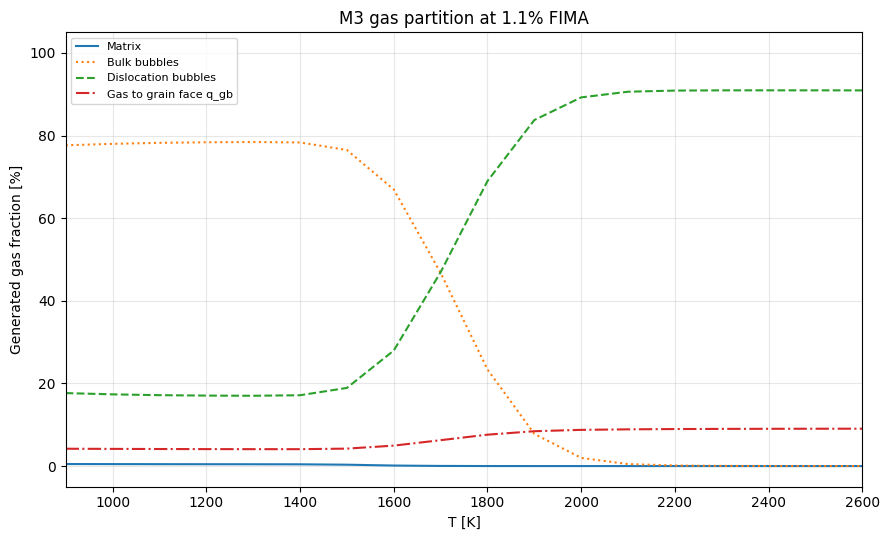

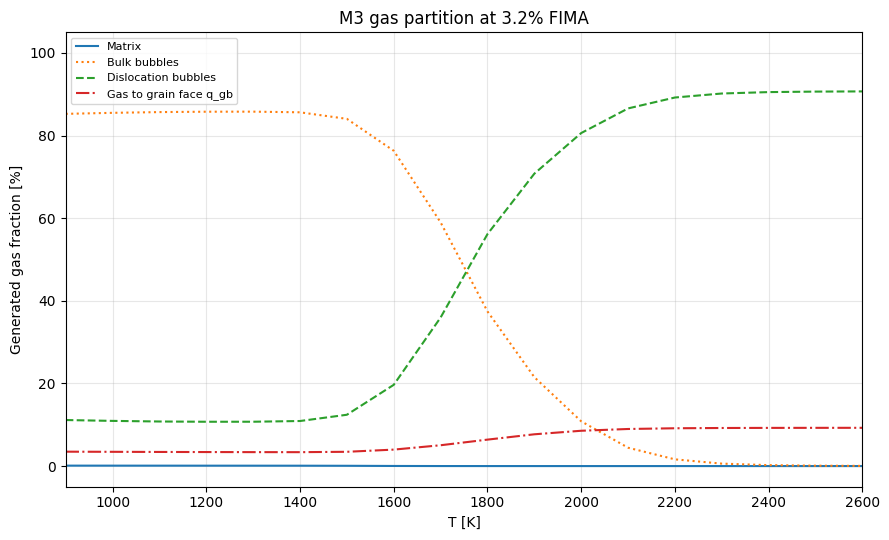

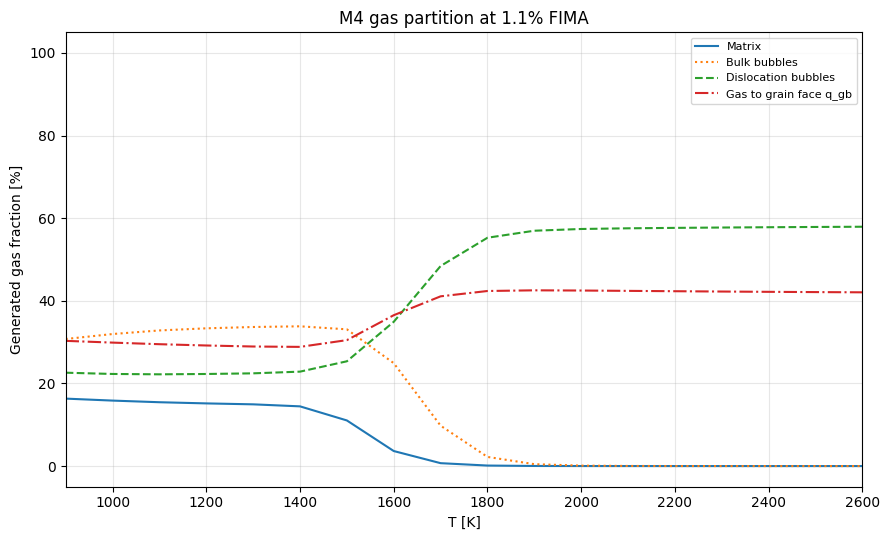

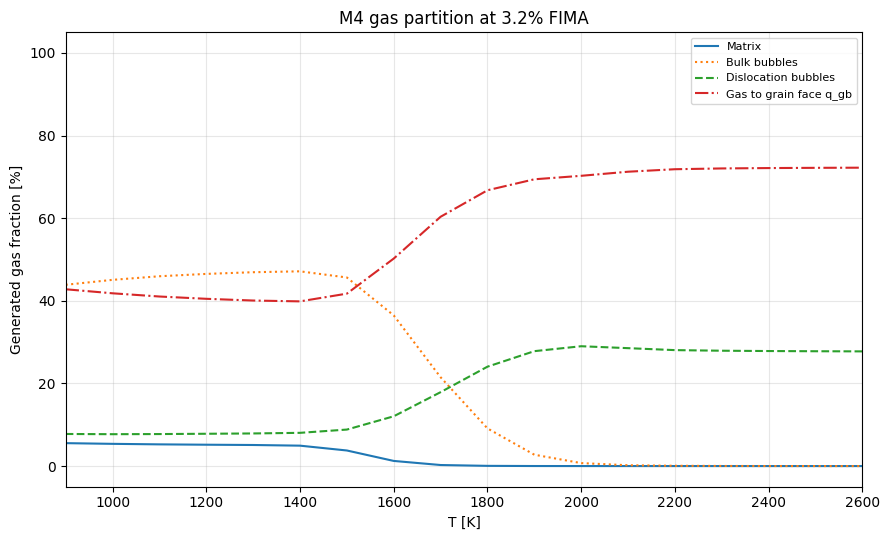

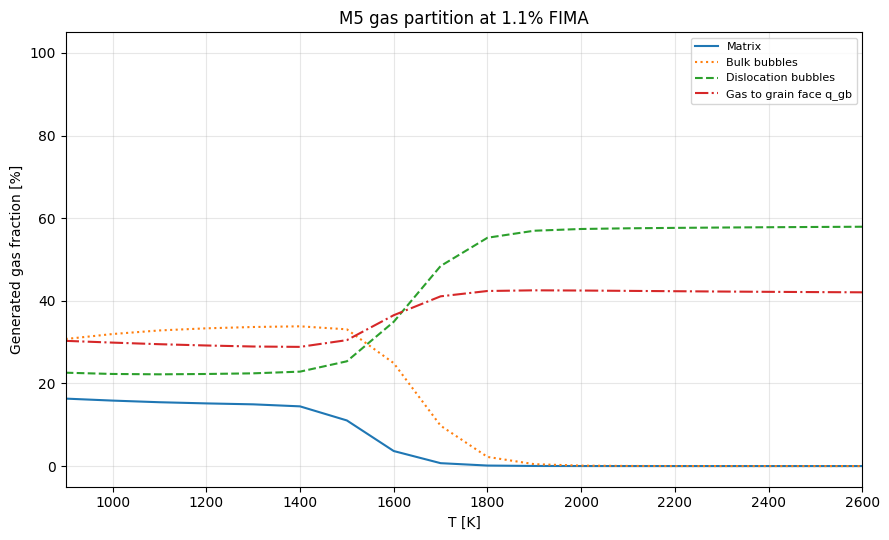

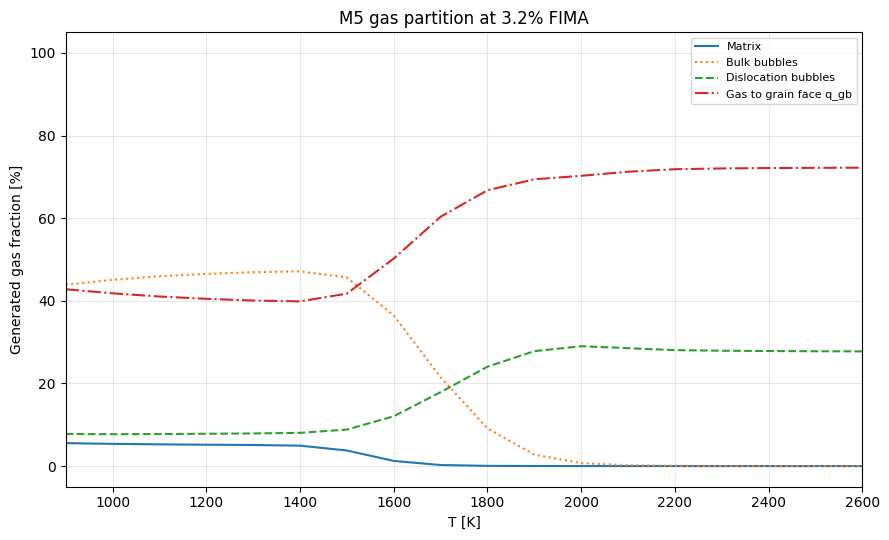

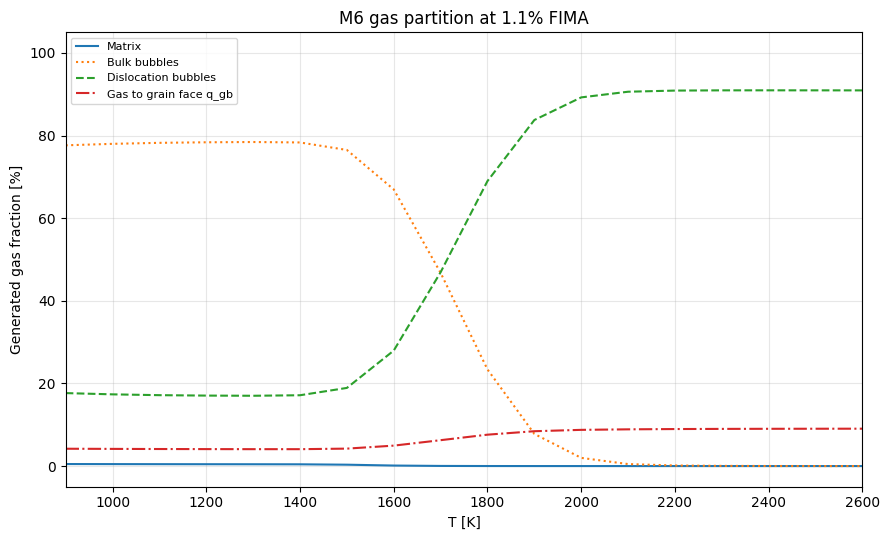

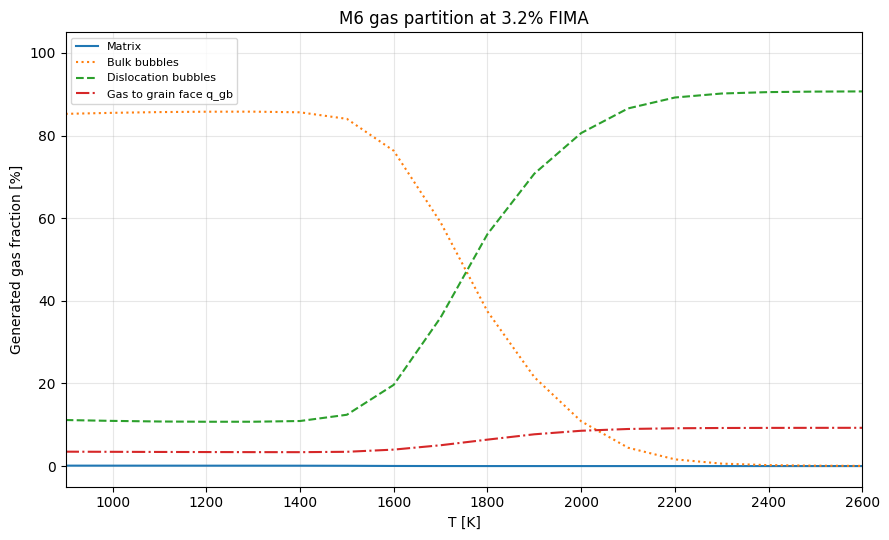


Fine diagnostiche.


In [5]:
# ============================================================
# MODEL VARIANTS DIAGNOSTICS - NOTEBOOK CELL
# ============================================================
# Incolla questa cella nel notebook dentro la cartella/progetto
# /home/destro/sciantix-official, oppure lascia PROJECT_DIR impostato.
#
# Cosa fa:
# - NON rifà la calibrazione.
# - Legge i best parameters da results_model_variants/variant_all_runs.csv
#   e/o variant_best_by_model.csv.
# - Se qualche modello manca nel CSV, usa fallback manuale dai risultati Codex.
# - Plotta M0-M6 insieme per swelling, R_d, N_d, R_b, N_b.
# - Plotta pressione separata per ogni modello.
# - Plotta gas partition separata per ogni modello.
# ============================================================

import os
import sys
import csv
import math
from pathlib import Path
from dataclasses import fields

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. CONFIGURAZIONE
# ------------------------------------------------------------

PROJECT_DIR = Path("/home/destro/sciantix-official")
RESULTS_DIR = PROJECT_DIR / "results_model_variants"
BEST_BY_MODEL_CSV = RESULTS_DIR / "variant_best_by_model.csv"
ALL_RUNS_CSV = RESULTS_DIR / "variant_all_runs.csv"

# Numerica per rifare i grafici diagnostici.
# Sono valori final-check ragionevoli, non la griglia super-fast.
PLOT_DT_H = 6.0
PLOT_N_MODES = 30

# Parametri fissi Rizk: NON cambiarli qui.
FISSION_RATE = 5.0e19
GRAIN_RADIUS = 6.0e-6
XE_YIELD = 0.24

# Griglie per i grafici.
T_GRID = [float(T) for T in range(900, 2001, 50)]
T_GRID_PARTITION = [float(T) for T in range(900, 2601, 100)]
BURNUPS_T = [1.1, 1.3, 3.2]
BURNUP_GRID_1600 = [0.2, 0.5, 0.8, 1.1, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0]

# True = zoom sul range sperimentale; le curve che esplodono vengono tagliate.
# False = mostra tutto, ma i punti sperimentali si schiacciano se qualche modello esplode.
FOCUS_EXPERIMENTAL_WINDOW = True
SWELLING_YLIM_BY_BU = {
    1.1: (0.0, 8.0),
    1.3: (0.0, 8.0),
    3.2: (0.0, 8.0),
}

# Se vuoi salvare anche PNG, metti True.
SAVE_FIGS = False
SAVE_DIR = RESULTS_DIR / "notebook_comparison_plots"

# Se True, stampa una tabella compatta a 1600 K e 1.3% FIMA.
PRINT_COMPACT_TABLES = True

# ------------------------------------------------------------
# 1. IMPORT DEL MODELLO NUOVO
# ------------------------------------------------------------

sys.path.insert(0, str(PROJECT_DIR))

import un_model
import un_data

if SAVE_FIGS:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

PARAM_NAMES = {f.name for f in fields(un_model.UNParameters)}

# ------------------------------------------------------------
# 2. DEFINIZIONE VARIANTI FISICHE
# ------------------------------------------------------------

# Nota:
# - M1 ha la stessa fisica di M0. Cambia solo il modo in cui era stato fatto lo score.
# - M3 qui usa bulk_and_dislocation, cioè la forma più forte del test phi.
# - M6 = phi bulk_and_dislocation + capture.
DEFAULT_MODEL_FLAGS = {
    "M0": {},
    "M1": {},
    "M2": {"nucleation_gas_coupling": True},
    "M3": {"phi_resolution_mode": "bulk_and_dislocation"},
    "M4": {"bulk_dislocation_capture": True},
    "M5": {"nucleation_gas_coupling": True, "bulk_dislocation_capture": True},
    "M6": {"phi_resolution_mode": "bulk_and_dislocation", "bulk_dislocation_capture": True},
}

MODEL_LABELS = {
    "M0": "M0 baseline",
    "M1": "M1 baseline, P2 score",
    "M2": "M2 nucleation mass",
    "M3": "M3 phi resolution",
    "M4": "M4 bulk-dislocation capture",
    "M5": "M5 nucleation mass + capture",
    "M6": "M6 phi + capture",
}

# Fallback dai risultati comunicati da Codex.
# Serve solo se i CSV non contengono/rendono leggibili tutte le righe M0-M6.
FALLBACK_BEST_ROWS = {
    "M0": {"f_n": 1.0e-10, "K_d": 3.0e5, "g_d_scale": 0.5, "seed_nm": 0.0, "score": 1.33753},
    "M1": {"f_n": 1.0e-10, "K_d": 3.0e5, "g_d_scale": 0.5, "seed_nm": 0.0, "score": 1.33753},
    # M2/M4 erano visibili nella tabella già stampata nel notebook.
    "M2": {"f_n": 1.0e-9,  "K_d": 5.0e5, "g_d_scale": 1.0, "seed_nm": 0.0, "score": 1.2839},
    "M3": {"f_n": 3.0e-7,  "K_d": 3.0e5, "g_d_scale": 0.5, "seed_nm": 0.0, "score": 1.2690},
    "M4": {"f_n": 1.0e-9,  "K_d": 5.0e5, "g_d_scale": 1.0, "seed_nm": 0.0, "score": 1.2839},
    # Se il CSV non contiene M5, uso la scelta naturale vicina a M4/M2.
    # Se variant_all_runs.csv lo contiene, questo fallback viene sovrascritto.
    "M5": {"f_n": 1.0e-9,  "K_d": 5.0e5, "g_d_scale": 1.0, "seed_nm": 0.0, "score": 1.2839},
    "M6": {"f_n": 3.0e-7,  "K_d": 3.0e5, "g_d_scale": 0.5, "seed_nm": 0.0, "score": 1.26898},
}

# ------------------------------------------------------------
# 3. LETTURA ROBUSTA DEI CSV
# ------------------------------------------------------------

def read_csv_rows(path):
    if not Path(path).exists():
        return []
    with open(path, newline="") as f:
        return list(csv.DictReader(f))


def to_float(x, default=math.nan):
    try:
        if x is None or str(x).strip() == "":
            return default
        return float(x)
    except Exception:
        return default


def to_bool(x, default=False):
    if x is None:
        return default
    if isinstance(x, bool):
        return x
    s = str(x).strip().lower()
    if s in ("true", "1", "yes", "y", "on"):
        return True
    if s in ("false", "0", "no", "n", "off"):
        return False
    return default


def first_existing(row, candidates, default=None):
    for name in candidates:
        if name in row and row[name] not in (None, ""):
            return row[name]
    # fallback case-insensitive
    low = {k.lower(): k for k in row.keys()}
    for name in candidates:
        k = low.get(name.lower())
        if k is not None and row[k] not in (None, ""):
            return row[k]
    return default


def infer_model_key(row):
    # Cerca direttamente nei valori.
    text = " ".join(str(v) for v in row.values())
    for key in ["M0", "M1", "M2", "M3", "M4", "M5", "M6"]:
        if key in text:
            return key

    # Cerca dai flag se il modello non è scritto esplicitamente.
    nuc = to_bool(first_existing(row, ["nucleation_gas_coupling"], False))
    cap = to_bool(first_existing(row, ["bulk_dislocation_capture"], False))
    phi = str(first_existing(row, ["phi_resolution_mode"], "none")).strip().lower()

    if phi not in ("", "none", "false", "0") and cap:
        return "M6"
    if nuc and cap:
        return "M5"
    if cap:
        return "M4"
    if phi not in ("", "none", "false", "0"):
        return "M3"
    if nuc:
        return "M2"

    return None


def choose_score(row):
    # Preferenze esplicite.
    preferred = [
        "score_main", "score_total", "total_score", "score_p2", "score_final", "final_score",
        "score", "score_swd_total", "objective", "loss",
    ]
    for name in preferred:
        val = to_float(first_existing(row, [name], None))
        if math.isfinite(val):
            return val

    # Se non c'è uno score unico, somma i componenti principali se esistono.
    component_names = [
        "score_swd", "score_Rd", "score_rd", "score_Nd", "score_nd", "score_pressure",
        "pressure_penalty",
    ]
    vals = []
    for name in component_names:
        val = to_float(first_existing(row, [name], None))
        if math.isfinite(val):
            vals.append(val)
    if vals:
        return sum(vals)

    # Ultima chance: cerca colonne contenenti score numeriche e usa la prima finita.
    for k, v in row.items():
        if "score" in str(k).lower() or "loss" in str(k).lower():
            val = to_float(v)
            if math.isfinite(val):
                return val

    return math.inf


def parse_candidate_row(row):
    key = infer_model_key(row)
    if key is None:
        return None

    f_n = to_float(first_existing(row, ["f_n", "fn", "f_n_value"], None))
    K_d = to_float(first_existing(row, ["K_d", "Kd", "k_d", "kd"], None))
    g_d_scale = to_float(first_existing(row, ["g_d_scale", "gd_scale", "g_d_sf"], 1.0), 1.0)
    seed_nm = to_float(first_existing(row, ["seed_nm", "bulk_seed_radius_nm", "bulk_seed_nm"], 0.0), 0.0)

    if not math.isfinite(f_n) or not math.isfinite(K_d):
        return None

    score = choose_score(row)

    out = dict(row)
    out["_model_key"] = key
    out["f_n"] = f_n
    out["K_d"] = K_d
    out["g_d_scale"] = g_d_scale
    out["seed_nm"] = seed_nm
    out["_score"] = score
    return out


def load_best_rows():
    # Prima provo all_runs, perché contiene davvero tutte le varianti.
    sources = [ALL_RUNS_CSV, BEST_BY_MODEL_CSV]
    candidates_by_model = {}

    for source in sources:
        rows = read_csv_rows(source)
        for row in rows:
            cand = parse_candidate_row(row)
            if cand is None:
                continue
            key = cand["_model_key"]
            score = cand.get("_score", math.inf)
            if key not in candidates_by_model or score < candidates_by_model[key].get("_score", math.inf):
                cand["_source_csv"] = str(source)
                candidates_by_model[key] = cand

    # Riempio mancanti con fallback manuale.
    final = {}
    for key in ["M0", "M1", "M2", "M3", "M4", "M5", "M6"]:
        if key in candidates_by_model:
            final[key] = candidates_by_model[key]
            final[key]["_source"] = "csv"
        else:
            fb = dict(FALLBACK_BEST_ROWS[key])
            fb["_model_key"] = key
            fb["_score"] = fb.pop("score")
            fb["_source"] = "fallback"
            final[key] = fb

    # M1 è fisicamente uguale a M0. Se il CSV non lo ha, il fallback è corretto.
    return final


best_rows = load_best_rows()

print("Best parameters usati per i grafici")
print("CSV disponibili:")
print("  ", ALL_RUNS_CSV, "exists=", ALL_RUNS_CSV.exists())
print("  ", BEST_BY_MODEL_CSV, "exists=", BEST_BY_MODEL_CSV.exists())
print("-" * 132)
print(
    f"{'model':>5s} | {'label':>34s} | {'f_n':>12s} | {'K_d':>12s} | "
    f"{'g_d_scale':>10s} | {'seed_nm':>8s} | {'score':>12s} | {'source':>9s}"
)
print("-" * 132)
for key, row in best_rows.items():
    print(
        f"{key:>5s} | {MODEL_LABELS[key]:>34s} | "
        f"{row['f_n']:12.3e} | {row['K_d']:12.3e} | "
        f"{row['g_d_scale']:10.3g} | {row['seed_nm']:8.3g} | "
        f"{row.get('_score', math.nan):12.5g} | {row.get('_source', '?'):>9s}"
    )

# ------------------------------------------------------------
# 4. COSTRUZIONE PARAMETRI E RUN MODELLO
# ------------------------------------------------------------

def build_params_for_model(model_key, T, burnup):
    row = best_rows[model_key]
    flags = dict(DEFAULT_MODEL_FLAGS[model_key])

    # Se il CSV conteneva i flag espliciti, li uso.
    # I fallback restano quelli DEFAULT_MODEL_FLAGS.
    for flag_name in ["nucleation_gas_coupling", "bulk_dislocation_capture"]:
        if flag_name in row and row[flag_name] not in (None, ""):
            flags[flag_name] = to_bool(row[flag_name], flags.get(flag_name, False))

    if "phi_resolution_mode" in row and row["phi_resolution_mode"] not in (None, ""):
        flags["phi_resolution_mode"] = row["phi_resolution_mode"]

    kwargs = {
        "temperature": float(T),
        "fission_rate": FISSION_RATE,
        "grain_radius": GRAIN_RADIUS,
        "target_burnup_percent_fima": float(burnup),
        "dt": PLOT_DT_H * 3600.0,
        "n_modes": PLOT_N_MODES,
        "xe_yield": XE_YIELD,
        "f_n": float(row["f_n"]),
        "K_d": float(row["K_d"]),
        "R_b": 0.0,
        "N_b": 0.0,
        "R_d": 0.0,
        "N_d": None,
        "c0": 0.0,
        "mb0": 0.0,
        "md0": 0.0,
        "vacancy_absorption_only": True,
        "update_bulk_vacancies": True,
        "bulk_seed_radius_nm": float(row["seed_nm"]),
    }

    if "g_d_scale" in PARAM_NAMES:
        kwargs["g_d_scale"] = float(row["g_d_scale"])
    else:
        print("ATTENZIONE: UNParameters non contiene g_d_scale. Controlla un_model.py.")

    for name, value in flags.items():
        if name in PARAM_NAMES:
            kwargs[name] = value
        else:
            print(f"ATTENZIONE: UNParameters non contiene {name}. Flag ignorato per {model_key}.")

    kwargs = {k: v for k, v in kwargs.items() if k in PARAM_NAMES}
    return un_model.UNParameters(**kwargs)


_RUN_CACHE = {}


def safe_last(hist, key, default=math.nan):
    try:
        return hist[key][-1]
    except Exception:
        return default


def finite_or_nan(x, positive_for_log=False):
    try:
        x = float(x)
        if not math.isfinite(x):
            return math.nan
        if positive_for_log and x <= 0.0:
            return math.nan
        return x
    except Exception:
        return math.nan


def solve_model_point(model_key, T, burnup):
    cache_key = (model_key, round(float(T), 6), round(float(burnup), 6), PLOT_DT_H, PLOT_N_MODES)
    if cache_key in _RUN_CACHE:
        return _RUN_CACHE[cache_key]

    p = build_params_for_model(model_key, T, burnup)
    result = un_model.solve_UN_sciantix_intragranular_extended(p)

    if isinstance(result, tuple):
        hist = result[0]
        rates = result[1] if len(result) > 1 else {}
    else:
        hist = result
        rates = {}

    generated = safe_last(hist, "generated", 0.0)
    c = safe_last(hist, "c", 0.0)
    mb = safe_last(hist, "mb", 0.0)
    md = safe_last(hist, "md", 0.0)
    q_gb = safe_last(hist, "q_gb", 0.0)

    if generated > 0.0 and math.isfinite(generated):
        matrix_gas_percent = 100.0 * c / generated
        bulk_gas_percent = 100.0 * mb / generated
        dislocation_gas_percent = 100.0 * md / generated
        qgb_gas_percent = 100.0 * q_gb / generated
    else:
        matrix_gas_percent = math.nan
        bulk_gas_percent = math.nan
        dislocation_gas_percent = math.nan
        qgb_gas_percent = math.nan

    p_b = safe_last(hist, "p_b")
    p_d = safe_last(hist, "p_d")
    p_b_eq = safe_last(hist, "p_b_eq")
    p_d_eq = safe_last(hist, "p_d_eq")

    row = {
        "model": model_key,
        "T": float(T),
        "burnup": float(burnup),
        "swelling_b_percent": 100.0 * safe_last(hist, "swelling_b", 0.0),
        "swelling_d_percent": 100.0 * safe_last(hist, "swelling_d", 0.0),
        "swelling_ig_percent": 100.0 * safe_last(hist, "swelling_ig", 0.0),
        "Nb": safe_last(hist, "Nb"),
        "Nd": safe_last(hist, "Nd"),
        "Rb_nm": 1.0e9 * safe_last(hist, "Rb", 0.0),
        "Rd_nm": 1.0e9 * safe_last(hist, "Rd", 0.0),
        "p_b": p_b,
        "p_b_eq": p_b_eq,
        "p_d": p_d,
        "p_d_eq": p_d_eq,
        "p_b_over_eq": p_b / p_b_eq if p_b_eq and p_b_eq > 0 else math.nan,
        "p_d_over_eq": p_d / p_d_eq if p_d_eq and p_d_eq > 0 else math.nan,
        "matrix_gas_percent": matrix_gas_percent,
        "bulk_gas_percent": bulk_gas_percent,
        "dislocation_gas_percent": dislocation_gas_percent,
        "qgb_gas_percent": qgb_gas_percent,
        "hist": hist,
        "rates": rates,
    }

    _RUN_CACHE[cache_key] = row
    return row


def rows_for_T_grid(model_key, burnup, T_grid=T_GRID):
    return [solve_model_point(model_key, T, burnup) for T in T_grid]

# ------------------------------------------------------------
# 5. GRAFICI
# ------------------------------------------------------------

def savefig_optional(name):
    if SAVE_FIGS:
        path = SAVE_DIR / name
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("saved:", path)


def model_line_label(model_key):
    r = best_rows[model_key]
    return f"{model_key}: fn={r['f_n']:.0e}, Kd={r['K_d']:.0e}, gd={r['g_d_scale']:.1g}"


def plot_exp_swelling_for_burnup(bu):
    pts = [p for p in un_data.EXP_SWELLING_T if abs(float(p["burnup"]) - float(bu)) < 1.0e-9]
    series_names = sorted({p.get("series", "exp") for p in pts})

    for series in series_names:
        pp = [p for p in pts if p.get("series", "exp") == series]
        marker = "x" if "119" in str(series) else "^"
        plt.scatter(
            [p["T"] for p in pp],
            [p["swelling"] for p in pp],
            marker=marker,
            s=45,
            label=f"Exp {series}",
            zorder=5,
        )


def plot_all_models_vs_T(quantity, ylabel, title, burnup, yscale=None, exp_kind=None, filename=None, ylim=None):
    plt.figure(figsize=(10, 6))

    for model_key in best_rows.keys():
        rows = rows_for_T_grid(model_key, burnup)
        Ts = [r["T"] for r in rows]
        ys = [finite_or_nan(r[quantity], positive_for_log=(yscale == "log")) for r in rows]
        plt.plot(Ts, ys, label=model_line_label(model_key))

    if exp_kind == "swelling":
        plot_exp_swelling_for_burnup(burnup)
    elif exp_kind == "Nd":
        plt.scatter(
            [p["T"] for p in un_data.EXP_ND_T_13],
            [p["N"] for p in un_data.EXP_ND_T_13],
            marker="^",
            s=45,
            label="Exp large/P2 bubbles",
            zorder=5,
        )
    elif exp_kind == "Rd":
        plt.scatter(
            [p["T"] for p in un_data.EXP_RD_T_13],
            [p["R_nm"] for p in un_data.EXP_RD_T_13],
            marker="^",
            s=45,
            label="Exp large/P2 bubbles",
            zorder=5,
        )

    if yscale:
        plt.yscale(yscale)
    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("T [K]")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(ncol=1, fontsize=8)
    plt.tight_layout()
    if filename:
        savefig_optional(filename)
    plt.show()


def plot_swelling_vs_burnup_1600():
    plt.figure(figsize=(10, 6))

    for model_key in best_rows.keys():
        rows = [solve_model_point(model_key, 1600.0, bu) for bu in BURNUP_GRID_1600]
        plt.plot(
            BURNUP_GRID_1600,
            [r["swelling_d_percent"] for r in rows],
            label=model_line_label(model_key),
        )

    plt.scatter(
        [p["burnup"] for p in un_data.EXP_SWELLING_BURNUP_1600],
        [p["swelling"] for p in un_data.EXP_SWELLING_BURNUP_1600],
        marker="^",
        s=55,
        label="Exp approx",
        zorder=5,
    )

    if FOCUS_EXPERIMENTAL_WINDOW:
        plt.ylim(0.0, 8.0)

    plt.xlabel("Burnup [% FIMA]")
    plt.ylabel("Dislocation/P2 swelling [%]")
    plt.title("Swelling vs burnup at 1600 K - all best models")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=1, fontsize=8)
    plt.tight_layout()
    savefig_optional("all_models_swelling_vs_burnup_1600.png")
    plt.show()


def plot_pressure_diagnostic_per_model(burnup=3.2):
    for model_key in best_rows.keys():
        rows = rows_for_T_grid(model_key, burnup)
        Ts = [r["T"] for r in rows]

        plt.figure(figsize=(9, 5.5))
        plt.plot(Ts, [finite_or_nan(r["p_b"], True) for r in rows], label="Bulk p")
        plt.plot(Ts, [finite_or_nan(r["p_b_eq"], True) for r in rows], linestyle=":", label="Bulk p_eq")
        plt.plot(Ts, [finite_or_nan(r["p_d"], True) for r in rows], label="Dislocation p")
        plt.plot(Ts, [finite_or_nan(r["p_d_eq"], True) for r in rows], linestyle="--", label="Dislocation p_eq")

        plt.yscale("log")
        plt.xlabel("T [K]")
        plt.ylabel("Pressure [Pa]")
        plt.title(f"{model_key} pressure diagnostic at {burnup:.1f}% FIMA")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        savefig_optional(f"{model_key}_pressure_diagnostic.png")
        plt.show()


def plot_pressure_ratio_per_model(burnup=3.2):
    for model_key in best_rows.keys():
        rows = rows_for_T_grid(model_key, burnup)
        Ts = [r["T"] for r in rows]

        plt.figure(figsize=(9, 5.5))
        plt.plot(Ts, [finite_or_nan(r["p_b_over_eq"], True) for r in rows], label="Bulk p/p_eq")
        plt.plot(Ts, [finite_or_nan(r["p_d_over_eq"], True) for r in rows], label="Dislocation p/p_eq")
        plt.axhline(1.0, linestyle=":", label="equilibrium")

        plt.yscale("log")
        plt.xlabel("T [K]")
        plt.ylabel("p / p_eq [-]")
        plt.title(f"{model_key} pressure ratio diagnostic at {burnup:.1f}% FIMA")
        plt.grid(True, which="both", alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        savefig_optional(f"{model_key}_pressure_ratio_diagnostic.png")
        plt.show()


def plot_gas_partition_per_model(burnups=(1.1, 3.2)):
    for model_key in best_rows.keys():
        for bu in burnups:
            rows = [solve_model_point(model_key, T, bu) for T in T_GRID_PARTITION]
            Ts = [r["T"] for r in rows]

            plt.figure(figsize=(9, 5.5))
            plt.plot(Ts, [r["matrix_gas_percent"] for r in rows], label="Matrix")
            plt.plot(Ts, [r["bulk_gas_percent"] for r in rows], linestyle=":", label="Bulk bubbles")
            plt.plot(Ts, [r["dislocation_gas_percent"] for r in rows], linestyle="--", label="Dislocation bubbles")
            plt.plot(Ts, [r["qgb_gas_percent"] for r in rows], linestyle="-.", label="Gas to grain face q_gb")

            plt.xlabel("T [K]")
            plt.ylabel("Generated gas fraction [%]")
            plt.title(f"{model_key} gas partition at {bu:.1f}% FIMA")
            plt.xlim(min(T_GRID_PARTITION), max(T_GRID_PARTITION))
            plt.ylim(-5, 105)
            plt.grid(True, alpha=0.3)
            plt.legend(fontsize=8)
            plt.tight_layout()
            savefig_optional(f"{model_key}_gas_partition_{bu:.1f}FIMA.png".replace(".", "p"))
            plt.show()

# ------------------------------------------------------------
# 6. TABELLE COMPATTE
# ------------------------------------------------------------

def print_compact_table(T=1600.0, burnup=1.3):
    print("\n" + "=" * 150)
    print(f"COMPACT CHECK AT T={T:.0f} K, burnup={burnup:.1f}% FIMA")
    print("=" * 150)
    print(
        f"{'model':>5s} | {'sw_d_%':>10s} | {'sw_b_%':>10s} | {'sw_ig_%':>10s} | "
        f"{'Rd_nm':>10s} | {'Nd':>12s} | {'Rb_nm':>10s} | {'Nb':>12s} | "
        f"{'pd/peq':>10s} | {'pb/peq':>10s} | {'matrix_%':>10s} | {'bulkGas_%':>10s} | {'dislGas_%':>10s} | {'qgb_%':>10s}"
    )
    print("-" * 150)
    for model_key in best_rows.keys():
        r = solve_model_point(model_key, T, burnup)
        print(
            f"{model_key:>5s} | "
            f"{r['swelling_d_percent']:10.4e} | {r['swelling_b_percent']:10.4e} | {r['swelling_ig_percent']:10.4e} | "
            f"{r['Rd_nm']:10.4e} | {r['Nd']:12.5e} | {r['Rb_nm']:10.4e} | {r['Nb']:12.5e} | "
            f"{r['p_d_over_eq']:10.4e} | {r['p_b_over_eq']:10.4e} | "
            f"{r['matrix_gas_percent']:10.4e} | {r['bulk_gas_percent']:10.4e} | "
            f"{r['dislocation_gas_percent']:10.4e} | {r['qgb_gas_percent']:10.4e}"
        )

# ------------------------------------------------------------
# 7. ESECUZIONE GRAFICI
# ------------------------------------------------------------

print("\nInizio calcolo diagnostiche. Può richiedere qualche minuto.\n")

if PRINT_COMPACT_TABLES:
    print_compact_table(T=1600.0, burnup=1.3)
    print_compact_table(T=1600.0, burnup=3.2)

# 1) Swelling P2/dislocation: tutti i modelli insieme.
for bu in BURNUPS_T:
    ylim = SWELLING_YLIM_BY_BU.get(bu) if FOCUS_EXPERIMENTAL_WINDOW else None
    plot_all_models_vs_T(
        quantity="swelling_d_percent",
        ylabel="Dislocation / P2 swelling [%]",
        title=f"Dislocation/P2 swelling vs T at {bu:.1f}% FIMA - all best models",
        burnup=bu,
        yscale=None,
        exp_kind="swelling",
        filename=f"all_models_swelling_d_{bu:.1f}FIMA.png".replace(".", "p"),
        ylim=ylim,
    )

# 2) Swelling totale intragranulare: diagnostica, tutti i modelli insieme.
for bu in BURNUPS_T:
    ylim = SWELLING_YLIM_BY_BU.get(bu) if FOCUS_EXPERIMENTAL_WINDOW else None
    plot_all_models_vs_T(
        quantity="swelling_ig_percent",
        ylabel="Total intragranular swelling [%]",
        title=f"Total intragranular swelling vs T at {bu:.1f}% FIMA - diagnostic",
        burnup=bu,
        yscale=None,
        exp_kind="swelling",
        filename=f"all_models_swelling_ig_{bu:.1f}FIMA.png".replace(".", "p"),
        ylim=ylim,
    )

# 3) Swelling vs burnup a 1600 K.
plot_swelling_vs_burnup_1600()

# 4) Number density dislocation bubbles, tutti i modelli insieme.
plot_all_models_vs_T(
    quantity="Nd",
    ylabel="Dislocation bubble concentration $N_d$ [m$^{-3}$]",
    title="Dislocation bubble concentration at 1.3% FIMA - all best models",
    burnup=1.3,
    yscale="log",
    exp_kind="Nd",
    filename="all_models_Nd_1p3FIMA.png",
)

# 5) Radius dislocation bubbles, tutti i modelli insieme.
plot_all_models_vs_T(
    quantity="Rd_nm",
    ylabel="Dislocation bubble radius $R_d$ [nm]",
    title="Dislocation bubble radius at 1.3% FIMA - all best models",
    burnup=1.3,
    yscale="log",
    exp_kind="Rd",
    filename="all_models_Rd_1p3FIMA.png",
)

# 6) Bulk diagnostics, tutti i modelli insieme.
plot_all_models_vs_T(
    quantity="Nb",
    ylabel="Bulk bubble concentration $N_b$ [m$^{-3}$]",
    title="Bulk bubble concentration at 1.3% FIMA - diagnostic",
    burnup=1.3,
    yscale="log",
    exp_kind=None,
    filename="all_models_Nb_1p3FIMA.png",
)

plot_all_models_vs_T(
    quantity="Rb_nm",
    ylabel="Bulk bubble radius $R_b$ [nm]",
    title="Bulk bubble radius at 1.3% FIMA - diagnostic",
    burnup=1.3,
    yscale="log",
    exp_kind=None,
    filename="all_models_Rb_1p3FIMA.png",
)

# 7) Pressure: separato per modello.
plot_pressure_diagnostic_per_model(burnup=3.2)

# 8) Pressure ratio: separato per modello.
plot_pressure_ratio_per_model(burnup=3.2)

# 9) Gas partition: separato per modello e burnup.
plot_gas_partition_per_model(burnups=(1.1, 3.2))

print("\nFine diagnostiche.")
